In [1]:
import cudf as pd, numpy as np, matplotlib.pyplot as plt, json, os

# Microdatos del Censo 2024

## Introducción

La liberación del los datos del censo 2024 de vivienda y personas es fundamental para la investigación, toma de decisiones y el diseño de políticas públicas. 

Dado que estos contienen información __sensible__ (definidas según la ley 21.719 sobre proyección de datos personales), el INE debe aplicar distintos métodos para proteger la identidad de las personas y asegurar el __secreto estadístico__ (ley 17.374 sobre la creación del INE). 

Este mandato provoca un desafío natural, proteger la privacidad de las personas, al mismo tiempo que se mantiene la útilidad estadística de los datos. Entre los cambios más importantes para la liberación de los últimos microdatos, el INE decidió que la máxima desagregación geográfica fuera __comuna__. Para niveles geográficos más pequeños, se liberaron los conteos de ciertas características. 

Esto genera un problema y plantea una pregunta, primero __no existen datos desagregados a nivel de manzana__ y segundo, *¿Cómo podemos generar datos sintéticos desagregados a nivel de manzana?*. El objetivo de este trabajo es generar una base de microdatos a nivel de manzana.

_Secreto estadístico: Obligación legal de mantener en absoluta reserva la información individual entregada a los organismos que conforman el Sistema Estadístico Nacional._    

## Análisis Exploratorio

In [2]:
df_personas  = pd.read_csv(os.path.join("databases","personas_censo2024.csv"), sep=";")
df_hogares   = pd.read_csv(os.path.join("databases","hogares_censo2024.csv"), sep=";")
df_viviendas = pd.read_csv(os.path.join("databases","viviendas_censo2024.csv"), sep=";")
df_manzanas  = pd.read_csv(os.path.join("databases","Base_manzana_entidad_CPV24.csv"), sep=";")

### Microdatos nivel comuna

In [3]:
display(df_personas.head())
len(df_personas)

,id_vivienda,id_hogar,id_persona,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,sexo,...,p45_medio_transporte,p46a_tot_hijs_nac,p46b_hijas_nac,p46c_hijos_nac,p47a_tot_hijs_sobrev,p47b_hijas_sobrev,p47c_hijos_sobrev,p48_anio_nac_uh,p48_mes_nac_uh,div_genero
0,1,1,1,5,58,5802,2,1,2,2,...,<NA>,3,2,1,3,2,1,1978,7,2
1,1,1,2,5,58,5802,2,1,2,1,...,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2
2,1,1,3,5,58,5802,2,1,2,2,...,3,1,1,0,1,1,0,2015,9,2
3,1,1,4,5,58,5802,2,1,2,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2,1,1,4,43,4303,2,2,2,1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,-66


18480432

In [4]:
df_personas.columns

Index(['id_vivienda', 'id_hogar', 'id_persona', 'region', 'provincia',
       'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo', 'sexo',
       'edad', 'edad_quinquenal', 'parentesco', 'p23_est_civil',
       'p24_lug_resid5', 'p24_lug_resid5_esp', 'p25_lug_nacimiento',
       'p25_lug_nacimiento_rec', 'p25_lug_nacimiento_esp',
       'p26_llegada_periodo', 'p27_nacionalidad', 'p27_nacionalidad_esp',
       'p27_nacionalidad_rec', 'p28_autoid_pueblo', 'p28_pueblo_pert',
       'p29_afrodescendencia_rec', 'p29_afrodescendencia',
       'p30_lengua_indigena', 'p30_lengua_indigena_rec', 'p31_religion',
       'p31_religion_rec', 'p32a_dificultad_ver', 'p32b_dificultad_oir',
       'p32c_dificultad_mover', 'p32d_dificultad_cogni',
       'p32e_dificultad_cuidado', 'p32f_dificultad_comunic', 'discapacidad',
       'p33_edu_asiste', 'asistencia_parv', 'asistencia_basica',
       'asistencia_media', 'asistencia_superior', 'p37_alfabet', 'escolaridad',
       'cine11', 'sit_fuerza_traba

Cada fila corresponde a una persona censada, estos datos contienen información como por ejemplo:
+ Comuna 
+ Sexo
+ Edad (en años cumplidos)
+ Medio de transporte más usado
+ Pertenencia a pueblo originario
+ Religión

In [5]:
display(df_viviendas.head())
len(df_viviendas)

,id_vivienda,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,cant_hog,cant_per,p2_tipo_vivienda,...,p5_num_dormitorios,p6_fuente_agua,p7_distrib_agua,p8_serv_hig,p9_fuente_elect,p10_basura,p11a_num_personas,p11b_comparte_gasto,p11c_num_hogar,indice_hacinamiento
0,1,5,58,5802,2,1,2,1,4,1,...,2,1,1,1,1,1,4,1,<NA>,1
1,2,4,43,4303,2,2,2,1,3,1,...,2,1,1,3,1,1,3,1,<NA>,1
2,3,11,112,11202,1,1,2,1,3,1,...,3,1,1,1,1,1,3,1,<NA>,1
3,4,1,11,1101,2,1,2,1,3,3,...,2,1,1,1,1,1,3,1,<NA>,1
4,5,8,83,8301,2,1,2,1,1,1,...,1,1,1,1,1,1,1,<NA>,<NA>,1


7664466

In [6]:
df_viviendas.columns

Index(['id_vivienda', 'region', 'provincia', 'comuna', 'comuna_bajo_umbral',
       'area', 'tipo_operativo', 'cant_hog', 'cant_per', 'p2_tipo_vivienda',
       'p3a_estado_ocupacion', 'p3b_estado_ocupacion', 'p4a_mat_paredes',
       'p4b_mat_techo', 'p4c_mat_piso', 'p5_num_dormitorios', 'p6_fuente_agua',
       'p7_distrib_agua', 'p8_serv_hig', 'p9_fuente_elect', 'p10_basura',
       'p11a_num_personas', 'p11b_comparte_gasto', 'p11c_num_hogar',
       'indice_hacinamiento'],
      dtype='object')

Contiene información sobre la vivienda de las personas, enfocandose en los aspectos físicos de esta, por ejemplo:
+ Tipo de vivienda
+ Material de las paredes 
+ Material del piso
+ Número de dormitorios

In [7]:
display(df_hogares.head())
len(df_hogares)

,id_vivienda,id_hogar,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,p12_tenencia_viv,p13_comb_cocina,p14_comb_calefaccion,p15a_serv_tel_movil,p15b_serv_compu,p15c_serv_tablet,p15d_serv_internet_fija,p15e_serv_internet_movil,p15f_serv_internet_satelital,tipologia_hogar
0,1,1,5,58,5802,2,1,2,4,1,8,1,2,2,2,1,2,5
1,2,1,4,43,4303,2,2,2,9,1,3,1,2,2,2,1,2,7
2,3,1,11,112,11202,1,1,2,3,1,3,1,2,2,2,1,2,4
3,4,1,1,11,1101,2,1,2,3,1,1,1,1,1,1,1,2,4
4,5,1,8,83,8301,2,1,2,1,1,2,1,2,1,1,1,2,1


6622597

In [8]:
df_hogares.columns

Index(['id_vivienda', 'id_hogar', 'region', 'provincia', 'comuna',
       'comuna_bajo_umbral', 'area', 'tipo_operativo', 'p12_tenencia_viv',
       'p13_comb_cocina', 'p14_comb_calefaccion', 'p15a_serv_tel_movil',
       'p15b_serv_compu', 'p15c_serv_tablet', 'p15d_serv_internet_fija',
       'p15e_serv_internet_movil', 'p15f_serv_internet_satelital',
       'tipologia_hogar'],
      dtype='object')

Contiene información respecto al grupo social que vive en esa vivienda, enfocandose en la dínamica económica común. Dentro de las variables que miden tenemos: 
+ Tenencia (si es pagada, pagandose, arrendada, etc.)
+ Con que funciona la cocina
+ Principal fuente de calefacción
+ Tipología del hogar 
+ Servicio de internet

Es importante reecalcar que mediante las variables ```id_hogar``` y ```id_vivienda``` nos permite enlazar a cada persona con un hogar y vivienda.

### Datos nivel manzana - entidad

In [9]:
display(df_manzanas.head())
len(df_manzanas)

,CONTENEDOR_COMUNAL,COD_REGION,REGION,PROVINCIA,CUT,COMUNA,AREA_C,MANZENT,DISTRITO,COD_DISTRITO,...,n_fuente_elect_diesel,n_fuente_elect_solar,n_fuente_elect_eolica,n_fuente_elect_otro,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro
0,0,1,TARAPACÁ,IQUIQUE,1101,IQUIQUE,1,1101011001007,PUERTO,1,...,0,0,0,0,0,4,0,0,0,0
1,0,1,TARAPACÁ,IQUIQUE,1101,IQUIQUE,1,1101011001010,PUERTO,1,...,0,0,0,0,0,11,0,0,0,0
2,0,1,TARAPACÁ,IQUIQUE,1101,IQUIQUE,1,1101011001012,PUERTO,1,...,0,0,0,0,0,5,0,0,0,0
3,0,1,TARAPACÁ,IQUIQUE,1101,IQUIQUE,1,1101011001013,PUERTO,1,...,0,0,0,0,2,20,0,0,0,0
4,0,1,TARAPACÁ,IQUIQUE,1101,IQUIQUE,1,1101011001014,PUERTO,1,...,0,0,0,0,0,0,0,0,0,0


197032

In [10]:
list(df_manzanas.columns)

['CONTENEDOR_COMUNAL',
 'COD_REGION',
 'REGION',
 'PROVINCIA',
 'CUT',
 'COMUNA',
 'AREA_C',
 'MANZENT',
 'DISTRITO',
 'COD_DISTRITO',
 'COD_LOCALIDAD',
 'COD_ZONA',
 'LOCALIDAD',
 'COD_ENTIDAD',
 'COD_MANZANA',
 'ENTIDAD',
 'TIPO_MZ',
 'COD_CATEGORIA',
 'CATEGORIA',
 'ID_ENTIDAD',
 'ID_LOCALIDAD',
 'ID_DISTRITO',
 'ID_ZONA',
 'n_per',
 'n_hombres',
 'n_mujeres',
 'n_edad_0_5',
 'n_edad_6_13',
 'n_edad_14_17',
 'n_edad_18_24',
 'n_edad_25_44',
 'n_edad_45_59',
 'n_edad_60_mas',
 'prom_edad',
 'n_inmigrantes',
 'n_nacionalidad',
 'n_pueblos_orig',
 'n_afrodescendencia',
 'n_lengua_indigena',
 'n_religion',
 'n_dificultad_ver',
 'n_dificultad_oir',
 'n_dificultad_mover',
 'n_dificultad_cogni',
 'n_dificultad_cuidado',
 'n_dificultad_comunic',
 'n_discapacidad',
 'n_estcivcon_casado',
 'n_estcivcon_conviviente',
 'n_estcivcon_conv_civil',
 'n_estcivcon_anul_sep_div',
 'n_estcivcon_viudo',
 'n_estcivcon_soltero',
 'prom_escolaridad18',
 'n_asistencia_parv',
 'n_asistencia_basica',
 'n_asis

Contiene algunos estadísticos agregados sobre los 3 tópicos vistos arriba, personas, vivienda y hogar, alguno de estos conteos son:
+ Número de hombres
+ Número de Mujeres
+ Número de personas por edad quinquenal
+ Promedio de edad
+ Número de personas de pueblos originarios
+ Número de los estados civiles
+ Número de hogares unipersonales 
+ Número de viviendas con acceso a agua por red pública
+ Etc.

## Estructura 

Los datos tienen una estructura jerárquica de árbol. A nivel macro (comuna) conocemos la distribución conjunta real de la población, pero a nivel micro (manzana) solo disponemos de conteos marginales. Esto impone restricciones lógicas, como por ejemplo que la agregación de las distribuciones marginales, debemos reconstruir la distribución conjunta comunal. 

Nos gustaría hacer asignación espacial con garantías de privacidad para desagregar los datos a nivel de manzana, es decir, con cierto mecanismo de privacidad, nos gustaría a cada fila del dataset de personas, vivienda y hogares asignarle una manzana.

# El Problema de Transporte Óptimo Entrópico

Supongamos que nos gustaría estimar la distribución de los hombres por edad en una **comuna** que tiene **3 manzanas** y 1000 hombres.

De los datos que libera el INE tenemos:
+ Nivel macro (Comuna): Distribución por edad 
    - Jóvenes (0-17): 200
    - Adultos (18-64): 600
    - Mayores (65+): 200
+ Nivel micro (Manzana): Distribución de hombres
    - Manzana A: 500 hombres
    - Manzana B: 400 hombres
    - Manzana C: 100 hombres

Nuestro objetivo es descubrir como se cruza esta información, si lo tabulamos, nos encontramos con una matriz vacía:
| Edad / Manzana | A | B | C | Comuna |
| :-------------- | :-: | :-: | :-: | :------: |
| Jóvenes | ? | ? | ? | 200 |
| Adultos | ? | ? | ? | 600 |
| Mayores | ? | ? | ? | 200 |
| Manzana | 500 | 400 | 100 | 1000

Ahora, nuestro problema es encontrar valores para la matriz, ¿cómo lo hacemos?


## Transporte Óptimo Entrópico

Nuestro problema se vuelve a la creación de una matriz que respete las restricciones de las distribuciones marginales. Es decir, buscamos $P$ que minimice el "costo" de asignación espacial, regularizando por la entropía para suavizar la distribución.

Sea $\mu,\nu$ dos distribuciones de probabilidad y sea $C$ una matriz de costos (que tanto me cuesta mover masa de $\mu$ a $\nu$), buscamos una distribución $P$ en los couplings que minimice esta carga, es decir.

\begin{align*}
\min_{P} \quad&\sum_{i,j}P_{ij}C_{ij} - \epsilon H(P)\\ 
s.a \quad&P 1 = \mu \\ 
&P^T1 = \nu
\end{align*}
con $H(P) = -\sum_{ij}P_{ij}\log P_{ij}$.

En nuestro ejemplo:
+ $P$-Plan de transporte: la matriz vacía que queremos rellenar. Nos dirá cuántos jóvenes, adultos y mayores viven en las manzanas A, B y C.
+ $\mu$-Distribución de origen: El vector de edades de la comuna. Restricción de filas.
+ $\nu$-Distribución de destino: El vector de población del INE. Restricción de las columnas.
+ $C$-Matriz de costo: Es la lógica territorial, debe ser construida mediante información externa y por nosotros, hay que pensarlo como una penalización. En nuestro ejemplo, una manzana con mayoría de departamentos de 1-2 dormitorios podemos pensar que es menos probable que hayan jóvenes.
+ $\epsilon$-Parámetro de entropía: "Ruido", un valor mayor de este parámetro difumina más a los hombres entre manzanas.


## Pros y Contras de este modelo

+ Gracias a la regularización entrópica, el problema cuenta con solución analítica y se puede resolver de manera eficiente.
+ El problema es escalable y paralelizable.
+ No es claro que tanta privacidad entrega el parámetro $\epsilon$.
+ La matriz de costo $C$ es flexible, puede ser un pro y un contra a la vez.
+ El modelo produce distribuciones de probabilidad, por ejemplo, la solución nos puede entregar en una manzana 4.3 jóvenes y 2.7 adultos, nosotros necesitamos enteros. De todas formas, podemos muestrear con esta distribución.

# Ejercicio inicial: Comuna de Independecia

## Prueba de Concepto

Aplicamos este modelo a un caso real: **comuna de Independencia** (Región Metropolitana, CUT 13108), que tiene 470 manzanas y 116.943 personas. Trabajamos con una sola variable, **edad**, usando los mismos 7 tramos etarios que `df_manzanas` ya trae agregados por manzana (`'n_edad_0_5', n_edad_6_13', 'n_edad_14_17', 'n_edad_18_24', 'n_edad_25_44','n_edad_45_59','n_edad_60_mas'`).

Elegimos edad para esta prueba de concepto por una razón práctica: como esos 7 conteos ya existen en los datos publicados, podemos "ignorarlos" al momento de ajustar el modelo usando solo la población total por manzana (`n_per`) como restricción y compararlos al final contra el resultado reconstruido. Esto nos da un ground truth real para validar el método, sin tener que inventar uno sintético.

Concretamente, buscamos rellenar una matriz $P$ (7 tramos etarios × 470 manzanas) sujeta a dos restricciones marginales conocidas:

+ $\mu$ — **distribución de origen**: cuántas personas de la comuna caen en cada tramo etario (nivel comuna, de `df_personas`).
+ $\nu$ — **distribución de destino**: población total de cada manzana (nivel manzana, de `df_manzanas`).

Los conteos reales por tramo etario y manzana ($Y_{real}$) se guardan aparte, únicamente para la validación al final.

In [11]:
# Comuna de Independencia
COMUNA_CUT = 13108

df_personas_com = df_personas[df_personas['comuna'] == COMUNA_CUT]
df_manzanas_com = df_manzanas[df_manzanas['CUT'] == COMUNA_CUT]

df_manzanas_com['n_per'] = df_manzanas_com['n_per'].astype(int)
df_manzanas_com = df_manzanas_com[df_manzanas_com['n_per'] > 0]

len(df_personas_com), len(df_manzanas_com)

(116943, 469)

In [12]:
# Definimos los conjuntos de edad:
edad_brackets = [
    ("0_5",    0,   5),
    ("6_13",   6,  13),
    ("14_17", 14,  17),
    ("18_24", 18,  24),
    ("25_44", 25,  44),
    ("45_59", 45,  59),
    ("60_mas", 60, 130),
]

edad = df_personas_com["edad"]

# Distribución de origen (comuna): conteos por tramo etario
mu = np.array([int(((edad >= low) & (edad <= high)).sum()) for _, low, high in edad_brackets])

# Distribución de destino (manzana): población total por manzana
nu = df_manzanas_com['n_per'].to_numpy()

manzanas_ids = df_manzanas_com["MANZENT"].to_numpy()

print("mu (por tramo etario):", dict(zip([b[0] for b in edad_brackets], mu)))
print("suma mu:", mu.sum())
print("nu (primeras 10 manzanas):", nu[:10])
print("suma nu:", nu.sum(), "| n manzanas:", len(nu))

assert mu.sum() == nu.sum() == len(df_personas_com), "Error: la suma de mu y nu no coincide con el número total de personas en la comuna."

mu (por tramo etario): {'0_5': np.int64(7554), '6_13': np.int64(11542), '14_17': np.int64(5280), '18_24': np.int64(11439), '25_44': np.int64(44178), '45_59': np.int64(19274), '60_mas': np.int64(17676)}
suma mu: 116943
nu (primeras 10 manzanas): [  9 157 189 121 124 157 113 137 131 130]
suma nu: 116943 | n manzanas: 469


In [13]:
# Guardamos la distribución real de los conteos por tramo etario y por manzana
y_real_cols = ["n_edad_0_5", "n_edad_6_13", "n_edad_14_17", "n_edad_18_24",
               "n_edad_25_44", "n_edad_45_59", "n_edad_60_mas"]
Y_real = df_manzanas_com[y_real_cols].to_numpy().T
Y_real = Y_real.astype(int)
Y_real.shape

(7, 469)

In [14]:
# Construcción de C
C = np.zeros((len(mu), len(nu)), dtype=int)

In [15]:
# Algoritmo de Sinkhorn para obtener la matriz de transporte óptima
from scipy.special import logsumexp

def sinkhorn(mu, nu, C, eps, n_iter=1000, tol=1e-9):
    """
    Resuelve el transporte óptimo entrópico entre mu (m,) y nu (n,)
    con matriz de costo C (m,n) y regularización eps.
    Devuelve P (m,n) como distribución de probabilidad conjunta (suma 1).
    """
    mu_ = mu / mu.sum()
    nu_ = nu / nu.sum()
    log_mu, log_nu = np.log(mu_), np.log(nu_)

    f = np.zeros_like(mu_, dtype=float)
    g = np.zeros_like(nu_, dtype=float)

    for _ in range(n_iter):
        f_prev = f.copy()
        f = eps * (log_mu - logsumexp((g[None, :] - C) / eps, axis=1))
        g = eps * (log_nu - logsumexp((f[:, None] - C) / eps, axis=0))
        if np.max(np.abs(f - f_prev)) < tol:
            break

    logP = (f[:, None] + g[None, :] - C) / eps
    return np.exp(logP)

In [16]:
# Calculamos la matriz de transporte óptima P usando el algoritmo de Sinkhorn
P = sinkhorn(mu, nu, C, eps=1.0, n_iter=1000)

# Pasamos a una matriz de conteos esperados 
counts = (P * mu.sum())

# Chequeo: con C=0 el resultado debe ser ~ igual al producto exterior mu_i * nu_j / N
counts_analitico = np.outer(mu, nu) / mu.sum()
print("error máx vs solución analítica:", np.abs(counts - counts_analitico).max())

# Chequeo de marginales: filas deben sumar a mu, columnas a nu
print("error marginal filas:", np.abs(counts.sum(axis=1) - mu).max())
print("error marginal columnas:", np.abs(counts.sum(axis=0) - nu).max())

error máx vs solución analítica: 6.821210263296962e-13
error marginal filas: 1.4551915228366852e-11
error marginal columnas: 1.3642420526593924e-12


In [17]:
# Baseline: error de la reconstrucción "sin costo" (C=0) vs el dato real
abs_error = np.abs(counts - Y_real)
total_abs_error = abs_error.sum()

# SRMSE (Standardized RMSE), métrica estándar en síntesis de población (Voas & Williamson, 2001)
rmse = np.sqrt(np.mean((counts - Y_real) ** 2))
srmse = rmse / np.mean(Y_real)

print("error absoluto total:", total_abs_error)
print("error absoluto promedio por celda:", abs_error.mean())
print("SRMSE (baseline, sin costo):", srmse)

error absoluto total: 30565.27802433664
error absoluto promedio por celda: 9.310166927912471
SRMSE (baseline, sin costo): 0.794002538724482


Error muy alto, esperado al repartir a las personas de forma uniforme entre las manzanas, ignorando las diferencias de ellas.

Nueva matriz $C$, para un grupo etario $i$ y una manzana $j$, definimos
$$C_{ij}= \frac{(Mean_{i}-Mean_{j})^2}{std(C)}$$

Ahora asumimos que conocemos estos promedios,

In [42]:
# Construcción de otra matriz C
prom_edad_com = (df_manzanas_com["prom_edad"].astype(str).str.replace(",", ".", regex=False).astype(float).to_numpy()) # Recuperamos los valores promedio de edad por manzana
prom_edad_com = np.nan_to_num(prom_edad_com, nan=0)

edad_np = df_personas_com['edad'].to_numpy()

# Punto medio de cada tramo etario, calculado desde los datos reales
midpoints = np.array([edad_np[(edad_np >= low) & (edad_np <= high)].mean() for _, low, high in edad_brackets])
# Costo: distancia al cuadrado entre el punto medio del tramo y la edad promedio de la manzana
C = (midpoints[:, None] - prom_edad_com[None, :]) ** 2
C = C / C.std()  # normalizar escala para que eps sea comparable entre corridas

### Testeamos para varios $\epsilon$

In [19]:
for eps in [0.05, 0.1, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 5.0]:
    P = sinkhorn(mu, nu, C, eps, n_iter=20000, tol=1e-10)
    counts_c = P * mu.sum()
    row_err = np.abs(counts_c.sum(axis=1) - mu).max()
    col_err = np.abs(counts_c.sum(axis=0) - nu).max()
    rmse = np.sqrt(np.mean((counts_c - Y_real) ** 2))
    srmse = rmse / np.mean(Y_real)
    print(f"eps={eps:>5}: SRMSE={srmse:.4f} | err_fila={row_err:.4f} | err_col={col_err:.4f}")

    abs_error = np.abs(counts_c - Y_real)
    total_abs_error = abs_error.sum()

    print("error absoluto total:", total_abs_error)
    print("error absoluto promedio por celda:", abs_error.mean(),'\n')

eps= 0.05: SRMSE=2.9110 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 116367.79217353981
error absoluto promedio por celda: 35.445565694041974 

eps=  0.1: SRMSE=2.1551 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 93175.29526604943
error absoluto promedio por celda: 28.381143851979726 

eps=  0.5: SRMSE=0.7706 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 36629.82245579108
error absoluto promedio por celda: 11.157423836671057 

eps=  0.6: SRMSE=0.6780 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 31728.097719310565
error absoluto promedio por celda: 9.664361169451894 

eps=  0.7: SRMSE=0.6167 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 28083.451779618998
error absoluto promedio por celda: 8.554204014504721 

eps=  0.8: SRMSE=0.5778 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 25459.53343275753
error absoluto promedio por celda: 7.754959924690079 

eps=  0.9: SRMSE=0.5548 | err_fila=0.0000 | err_col=0.0000
error absol

## Estudio del error para la nueva matriz C

In [41]:
eps_best = 1.2
P_best = sinkhorn(mu, nu, C, eps_best, n_iter=20000, tol=1e-10)
counts_best = P_best * mu.sum()
counts_baseline = np.outer(mu, nu) / mu.sum()

labels = [b[0] for b in edad_brackets]

err_manzana_baseline = np.abs(counts_baseline - Y_real).sum(axis=0)  # (n_manzanas,)
err_manzana_model    = np.abs(counts_best     - Y_real).sum(axis=0)

mejora = err_manzana_baseline - err_manzana_model  # >0 = el modelo mejoró ahí

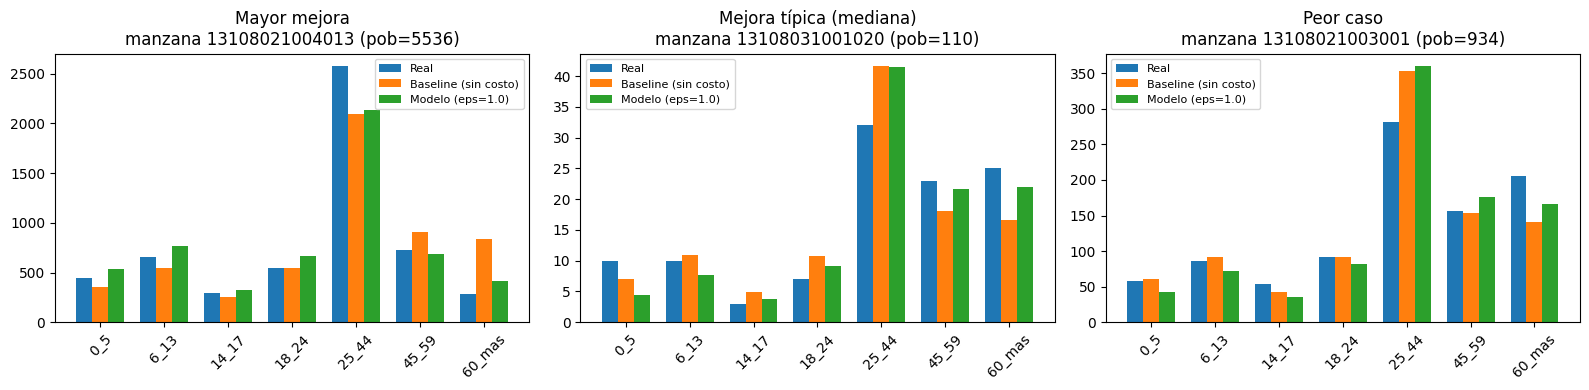

In [ ]:
idx_mejor  = np.argsort(-mejora)[0]
idx_typico = np.argsort(mejora)[len(mejora) // 2]
idx_peor   = np.argsort(mejora)[0]

manzanas_a_graficar = [idx_mejor, idx_typico, idx_peor]
titulos = ["Mayor mejora", "Mejora típica (mediana)", "Peor caso"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(labels))
width = 0.25

for ax, idx, titulo in zip(axes, manzanas_a_graficar, titulos):
    ax.bar(x - width, Y_real[:, idx], width, label="Real")
    ax.bar(x, counts_baseline[:, idx], width, label="Baseline (sin costo)")
    ax.bar(x + width, counts_best[:, idx], width, label="Modelo (eps=1.0)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_title(f"{titulo}\nmanzana {manzanas_ids[idx]} (pob={int(nu[idx])})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

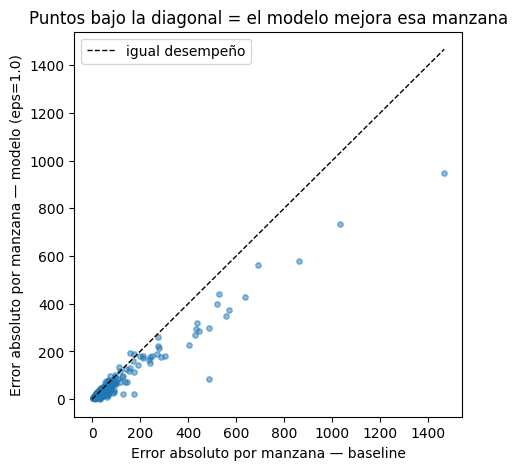

manzanas donde el modelo mejora: 379 / 469
manzanas donde el modelo empeora: 90 / 469


In [22]:
plt.figure(figsize=(5, 5))
plt.scatter(err_manzana_baseline, err_manzana_model, alpha=0.5, s=15)
lims = [0, max(err_manzana_baseline.max(), err_manzana_model.max())]
plt.plot(lims, lims, "k--", linewidth=1, label="igual desempeño")
plt.xlabel("Error absoluto por manzana — baseline")
plt.ylabel("Error absoluto por manzana — modelo (eps=1.0)")
plt.title("Puntos bajo la diagonal = el modelo mejora esa manzana")
plt.legend()
plt.show()

print(f"manzanas donde el modelo mejora: {(mejora > 0).sum()} / {len(mejora)}")
print(f"manzanas donde el modelo empeora: {(mejora < 0).sum()} / {len(mejora)}")

manzanas únicas en shapefile (comuna): 585
manzanas en el modelo: 469
intersección real: 461
manzanas del modelo encontradas en el shapefile: 461
manzanas sin error asignado (debería ser 0): 0


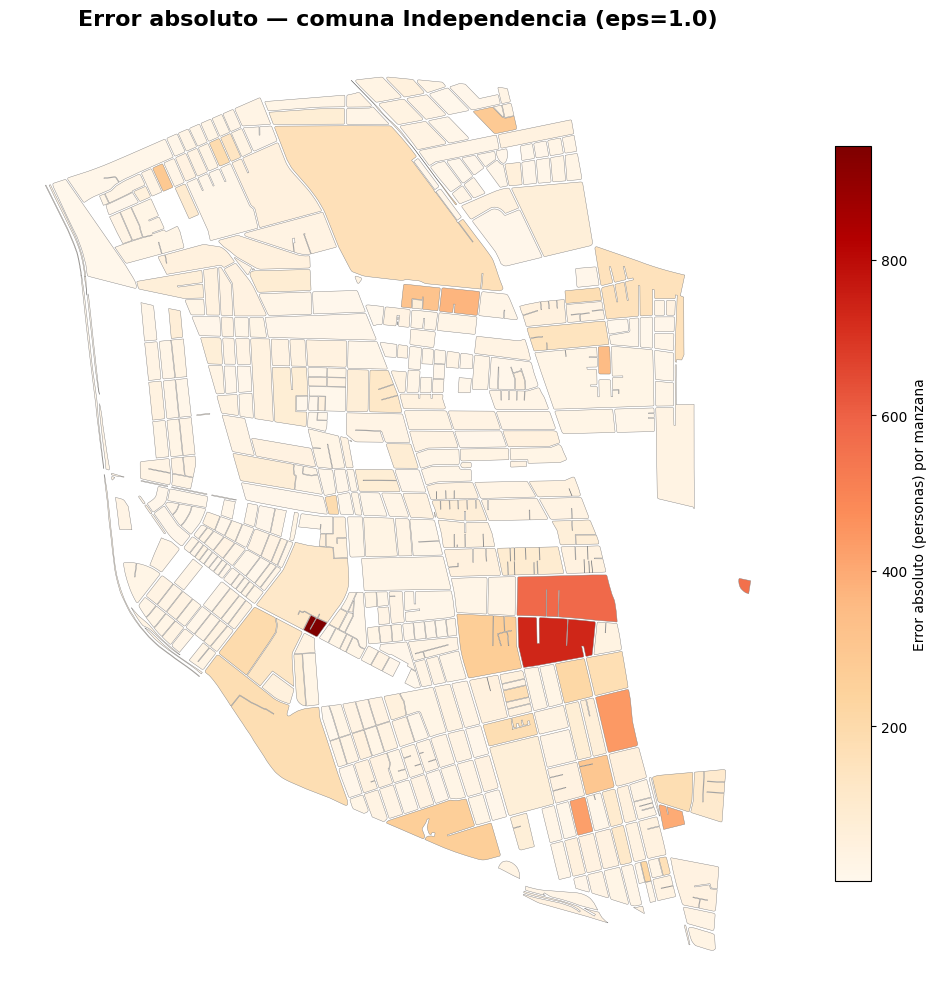

In [ ]:
import pandas as pand, geopandas as gpd
import matplotlib.pyplot as plt

comuna = 'INDEPENDENCIA'
shp_path = os.path.join('cartography', 'SHP_APC2023_R13/Manzana_Urbana.shp')

mapa = gpd.read_file(shp_path)
mapa['MANZENT'] = mapa['Mzent_TX'].astype(str).str.strip().astype(np.int64)

mapa_comuna = mapa[mapa['N_COMUNA'] == comuna]

# Diagnóstico: intersección real de códigos (no la muestra ordenada, que estaba dominada por un placeholder repetido)
set_mapa = set(mapa_comuna['MANZENT'].tolist())
set_censo = set(manzanas_ids.tolist())
print("manzanas únicas en shapefile (comuna):", len(set_mapa))
print("manzanas en el modelo:", len(set_censo))
print("intersección real:", len(set_mapa & set_censo))

# Filtrar solo las manzanas que realmente estamos modelando
mapa_filtrado = mapa_comuna[mapa_comuna['MANZENT'].isin(manzanas_ids)].copy()
print("manzanas del modelo encontradas en el shapefile:", len(mapa_filtrado))

# Unir el error por MANZENT explícitamente (nunca por posición/orden)
df_error = pand.DataFrame({
    "MANZENT": manzanas_ids,
    "absolute_error": err_manzana_model,
})
mapa_filtrado = mapa_filtrado.merge(df_error, on='MANZENT', how='left')
print("manzanas sin error asignado (debería ser 0):", mapa_filtrado['absolute_error'].isna().sum())

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 15))
mapa_filtrado.plot(
    column='absolute_error',
    cmap='OrRd',
    linewidth=0.3,
    ax=ax,
    edgecolor='0.5',
    legend=True,
    legend_kwds={
        'label': "Error absoluto (personas) por manzana",
        'orientation': "vertical",
        'shrink': 0.5,
    }
)
ax.axis('off')
ax.set_title('Error absoluto — comuna Independencia (eps=1.2)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()

In [44]:
set_mapa = set(mapa_comuna['MANZENT'].tolist())
set_censo = set(manzanas_ids.tolist())
faltantes = set_censo - set_mapa
print("manzanas del modelo sin geometría en el shapefile:", len(faltantes))
print(sorted(faltantes))

idx_faltantes = [i for i, m in enumerate(manzanas_ids) if m in faltantes]
print("población de esas manzanas:", nu[idx_faltantes])
print("error absoluto (eps=1.2) de esas manzanas:", err_manzana_model[idx_faltantes])
print("% de la población total de la comuna que representan:", nu[idx_faltantes].sum() / nu.sum() * 100)

manzanas del modelo sin geometría en el shapefile: 8
[13108021004014, 13108031004003, 13108051003001, 13108051003002, 13108051005004, 13108051005006, 13108061001027, 13108991999999]
población de esas manzanas: [  98   78  416   79 4576  630  165 1781]
error absoluto (eps=1.2) de esas manzanas: [ 31.47621762  34.60291758  92.8577236   28.63284957  85.16656266
  31.37646245  21.26165902 181.33217381]
% de la población total de la comuna que representan: 6.6895838143369


In [43]:
# Tabla comparativa: población real vs predicha por manzana y tramo etario
df_comparacion = pand.DataFrame({
    "MANZENT": manzanas_ids,
    "poblacion_total": nu,
    "error_absoluto_total": err_manzana_model,
})

for i, (nombre, _, _) in enumerate(edad_brackets):
    df_comparacion[f"real_{nombre}"] = Y_real[i]
    df_comparacion[f"pred_{nombre}"] = counts_best[i].round(1)

df_comparacion = df_comparacion.sort_values("error_absoluto_total", ascending=False)
df_comparacion.head(20)

,MANZENT,poblacion_total,error_absoluto_total,real_0_5,pred_0_5,real_6_13,pred_6_13,real_14_17,pred_14_17,real_18_24,pred_18_24,real_25_44,pred_25_44,real_45_59,pred_45_59,real_60_mas,pred_60_mas
177,13108021004013,5536,946.380555,450,540.1,655,768.4,293,328.4,550,662.2,2572,2137.2,727,688.6,289,411.1
457,13108061002008,4079,733.831414,281,356.4,408,520.9,151,227.9,481,470.3,1953,1596.7,510,551.3,295,355.3
453,13108061002004,4011,578.366668,294,336.4,406,496.6,155,219.1,429,455.9,1865,1575.8,542,557.7,320,369.4
459,13108071001001,3060,560.766255,225,265.2,289,388.4,122,170.2,361,351.9,1412,1198.8,474,416.0,177,269.6
65,13108011004003,2701,441.448534,175,222.8,263,330.2,117,146.2,302,305.2,1246,1062.5,417,379.8,181,254.3
83,13108011005014,2682,427.986389,218,261.7,328,372.3,130,159.1,298,320.8,1180,1035.4,403,333.6,125,199.2
462,13108071002004,1618,399.248153,156,171.5,166,238.9,74,100.2,166,198.4,805,615.6,198,187.8,53,105.6
337,13108041002004,1933,373.738894,158,187.2,230,266.8,78,114.2,199,230.6,934,747.1,220,241.9,114,145.2
409,13108051003011,3594,349.670723,268,272.5,357,411.8,140,185.4,354,393.5,1595,1420.2,522,533.4,358,377.2
335,13108041002002,1406,317.997398,125,125.8,120,182.9,53,79.6,144,163.5,708,549.0,165,186.8,91,118.4


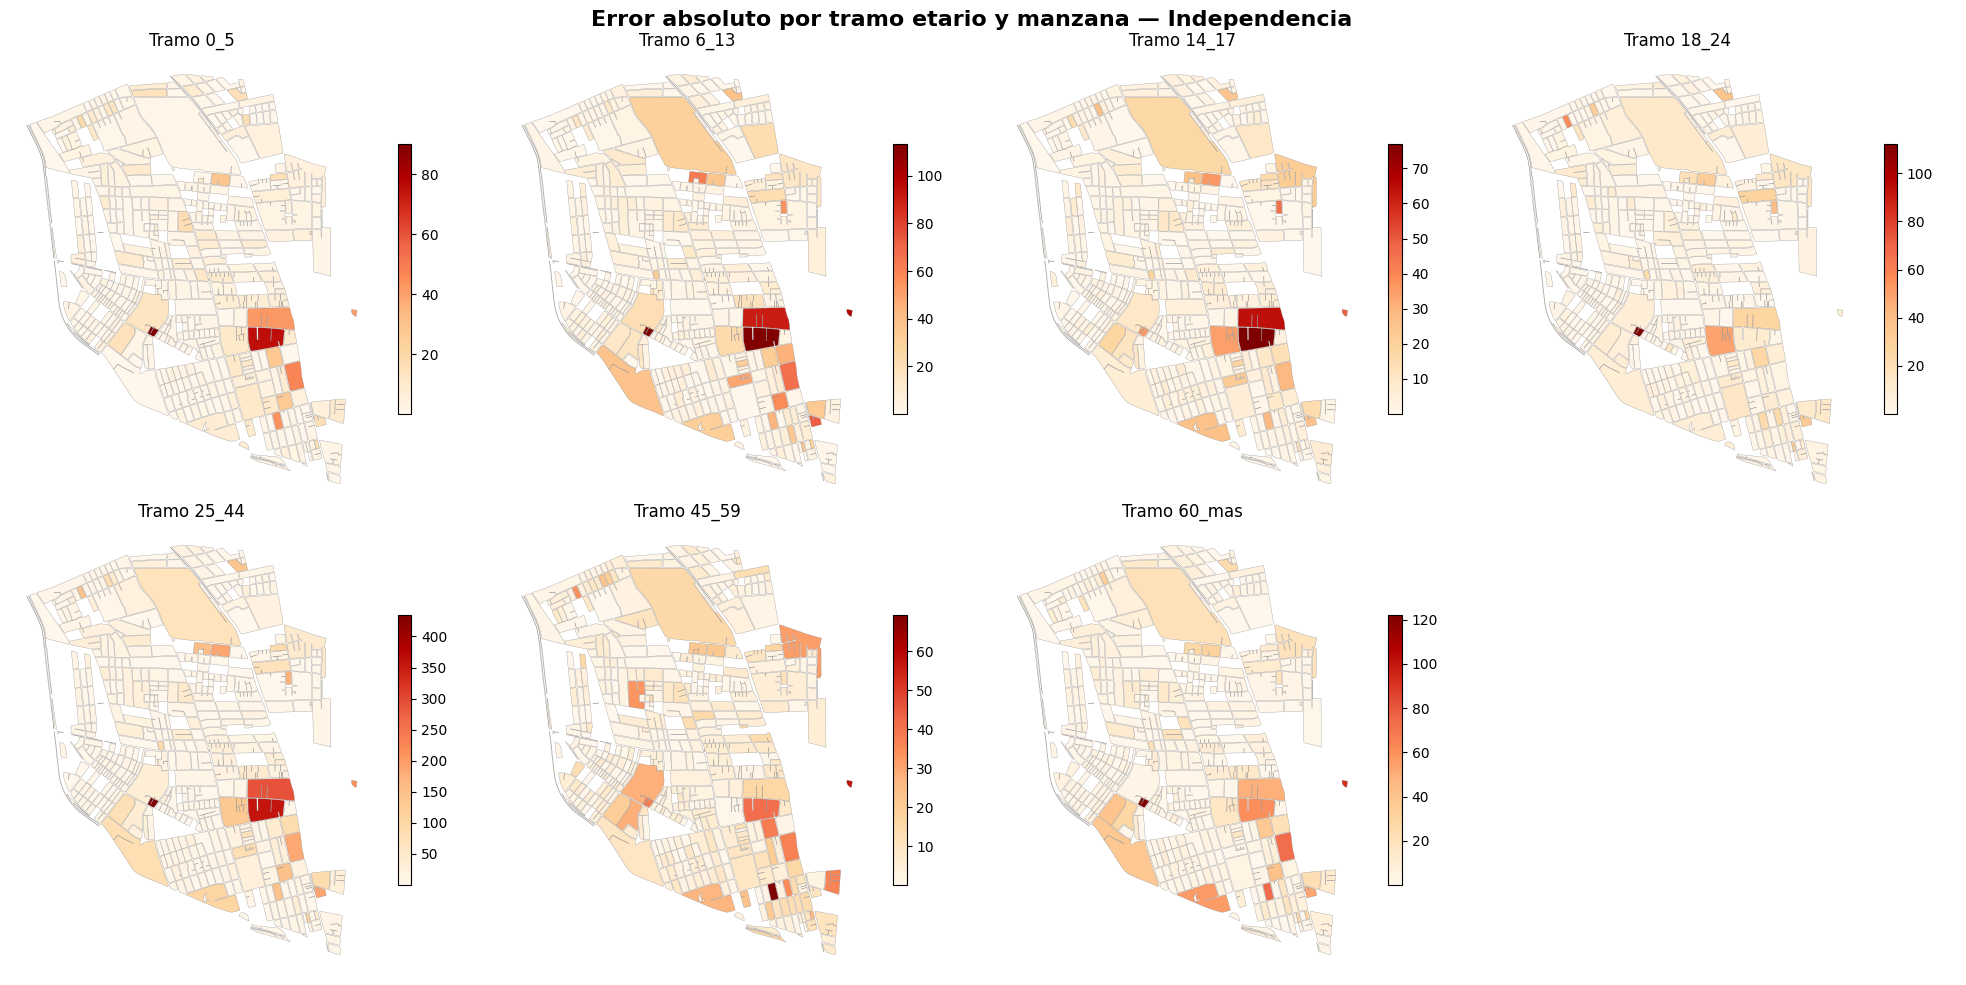

In [46]:
abs_error_bracket = np.abs(counts_best - Y_real)  # (7, n_manzanas), mismo orden que manzanas_ids

df_error_brackets = pand.DataFrame({"MANZENT": manzanas_ids})
for i, (nombre, _, _) in enumerate(edad_brackets):
    df_error_brackets[f"error_{nombre}"] = abs_error_bracket[i]

mapa_filtrado = mapa_filtrado.merge(df_error_brackets, on="MANZENT", how="left")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (nombre, _, _) in enumerate(edad_brackets):
    mapa_filtrado.plot(
        column=f"error_{nombre}",
        cmap='OrRd',
        linewidth=0.2,
        ax=axes[i],
        edgecolor='0.5',
        legend=True,
        legend_kwds={'shrink': 0.6},
    )
    axes[i].axis('off')
    axes[i].set_title(f"Tramo {nombre}", fontsize=12)

axes[-1].axis('off')  # sobra un subplot (7 tramos en grilla 2x4)
plt.suptitle('Error absoluto por tramo etario y manzana — Independencia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
set_mapa = set(mapa_comuna['MANZENT'].tolist())
set_censo = set(manzanas_ids.tolist())
faltantes = set_censo - set_mapa
idx_faltantes = [i for i, m in enumerate(manzanas_ids) if m in faltantes]

print("manzanas del modelo sin geometría en el shapefile:", len(faltantes))
print(sorted(faltantes))
print()

abs_error_bracket = np.abs(counts_best - Y_real)  # (7, n_manzanas), mismo orden que manzanas_ids

for i, (nombre, _, _) in enumerate(edad_brackets):
    print(f"--- Tramo {nombre} ---")
    print("población real de esas manzanas:", Y_real[i, idx_faltantes])
    print("error absoluto de esas manzanas:", abs_error_bracket[i, idx_faltantes])
    print("% de la población del tramo que representan:", Y_real[i, idx_faltantes].sum() / Y_real[i].sum() * 100)
    print()

manzanas del modelo sin geometría en el shapefile: 8
[13108021004014, 13108031004003, 13108051003001, 13108051003002, 13108051005004, 13108051005006, 13108061001027, 13108991999999]

--- Tramo 0_5 ---
población real de esas manzanas: [  8   6  22   0 345  33   8  76]
error absoluto de esas manzanas: [ 5.00002571  4.20086418 10.78916782  2.28333515  2.01775975 11.96051844
  2.65465428 15.76176114]
% de la población del tramo que representan: 6.59253375694996

--- Tramo 6_13 ---
población real de esas manzanas: [  6   4  34   8 517  75  13 147]
error absoluto de esas manzanas: [ 0.59155825  0.60173052 13.35243728  3.84337549  7.28311192  6.14292198
  3.45636295  3.41618842]
% de la población del tramo que representan: 6.965863801767458

--- Tramo 14_17 ---
población real de esas manzanas: [  5   7  13   3 224  30   5  54]
error absoluto de esas manzanas: [ 2.15874907  5.1407558   1.94924955  0.79781665 12.10968742  1.3792004
  0.02862984 18.73016826]
% de la población del tramo que repre

### Asignación de manzana

Dado que la solución nos entrega un resultado (probablemente fraccional), debemos redondear para tener conteos enteros que coincidan con los conteos reales.

Para esto, usaremos el algoritmo de __Largest Remainder Round__, que toma la función piso de cada población y luego asigna las unidades vacantes a aquellos con el resto más grande.


In [50]:
def largest_remainder_round(row, total):
    """Redondea una fila de conteos continuos a enteros que sumen exactamente `total`."""
    floor_vals = np.floor(row).astype(int)
    remainder = int(total - floor_vals.sum())
    frac = row - floor_vals
    idx = np.argsort(-frac)
    floor_vals[idx[:remainder]] += 1
    return floor_vals

counts_int = np.vstack([
    largest_remainder_round(counts[i], mu[i])
    for i in range(len(mu))
])

assert (counts_int.sum(axis=1) == mu).all()
counts_int.sum()  # debería dar 116943

np.int64(116943)

Cómo le asignamos a cada persona una manzana? en este caso como tenemos la característica de edad, podemos asignar de forma aleatoria.

In [51]:
rng = np.random.default_rng(42)

df_personas_com = df_personas_com.reset_index(drop=True)  # para que la posición sea inequívoca
edad_np = df_personas_com["edad"].to_numpy()
manzana_asignada = np.empty(len(df_personas_com), dtype=manzanas_ids.dtype)

for i, (_, lo, hi) in enumerate(edad_brackets):
    idx_bracket = np.where((edad_np >= lo) & (edad_np <= hi))[0]
    rng.shuffle(idx_bracket)  # el orden dentro del tramo no debe influir en la manzana asignada

    splits = np.cumsum(counts_int[i])[:-1]
    grupos = np.split(idx_bracket, splits)  # un grupo de personas por manzana

    for j, grupo in enumerate(grupos):
        manzana_asignada[grupo] = manzanas_ids[j]

df_personas_com["manzana_asignada"] = manzana_asignada

### Una posible dirección

En vez de usar solo tramos etarios, podemos usar la distribución conjunta (i.e. $edad\times sexo\times estado civil$), aumentando nuestra distribución de inicio $\mu$. En la llegada, podemos usar otros tipos de conteos como ```n_hombres```, ```n_mujeres```